# AutoGuard AI — Complete ML Pipeline

**Business problem.** AutoGuard AI is a car-insurance underwriting decision-support tool. When a driver
applies for a policy, the insurer needs an evidence-based estimate of whether that driver will file a
claim, so pricing and manual-review effort can be allocated consistently instead of by ad-hoc judgement.

**Target variable.** `OUTCOME` — a binary indicator, `1` if the policyholder filed a claim, `0` otherwise.

**Classification objective.** Learn `P(OUTCOME = 1 | driver attributes)` from historical policyholders and
turn it into an operational decision (approve / flag for review) at a chosen probability threshold.

**What this notebook does, end to end:** loads the single 50,000-record
dataset directly from `02_Data/`, runs data-quality checks and EDA, builds a leakage-safe Train/Validation/Test
split, fits a preprocessing pipeline on Train only, trains and compares a baseline, Logistic Regression,
Random Forest, and three distinct PyTorch neural networks, selects a model and a decision threshold using
Validation only, evaluates once on the untouched Test set, adds statistical validation, explains the final
model, analyzes its errors, and exports `model_v2.pkl` + `model_v2_metadata.json` for the Gradio and
production interfaces to consume.

In [1]:
import json, hashlib, random, sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve,
)

# Reproducibility: every source of randomness used below is seeded from this one constant.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def _find_project_root(start: Path) -> Path:
    """Walk up from `start` until a directory containing both 02_Data/ and
    01_ML_Model/ is found, so every path below resolves correctly whether
    this notebook is opened from the repo root, from inside 01_ML_Model/,
    or from any other working directory. Falls back to `start` unchanged
    (e.g. Google Colab), where the dataset loader below has its own
    upload-based fallback.
    """
    for candidate in [start, *start.parents]:
        if (candidate / "02_Data").is_dir() and (candidate / "01_ML_Model").is_dir():
            return candidate
    return start

PROJECT_ROOT = _find_project_root(Path.cwd())
ML_MODEL_DIR = PROJECT_ROOT / "01_ML_Model"
FIGDIR = ML_MODEL_DIR / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")
print("Environment ready. SEED =", SEED)
print("Project root resolved to:", PROJECT_ROOT)

Environment ready. SEED = 42
Project root resolved to: C:\Users\97252\Desktop\פרוייקט למידת מכונה הגשה 2026\AutoGuard_AI_FINAL_SUBMISSION


## 1. Dataset Loading

The only dataset used by this notebook is `02_Data/Car_Insurance_Claim_50000_FINAL.csv`. The loader below works whether the notebook is opened from the repo root, from inside `01_ML_Model/`, or uploaded standalone into Google Colab.

In [2]:
DATA_FILE = "Car_Insurance_Claim_50000_FINAL.csv"
CANDIDATES = [
    PROJECT_ROOT / "02_Data" / DATA_FILE,
    Path("../02_Data") / DATA_FILE,
    Path("02_Data") / DATA_FILE,
    Path(DATA_FILE),
]
path = next((p for p in CANDIDATES if p.exists()), None)
if path is None:
    try:
        from google.colab import files
        path = Path(next(iter(files.upload())))
    except ImportError:
        raise FileNotFoundError(f"Could not find {DATA_FILE} in {CANDIDATES}; place it beside this notebook.")

df = pd.read_csv(path)
assert len(df) == 50_000, f"Expected 50,000 records, found {len(df):,}"
assert {"ID", "OUTCOME"}.issubset(df.columns)
print("Loaded", path, "-> shape", df.shape)
display(df.head())
print("Columns:", list(df.columns))

Loaded C:\Users\97252\Desktop\פרוייקט למידת מכונה הגשה 2026\AutoGuard_AI_FINAL_SUBMISSION\02_Data\Car_Insurance_Claim_50000_FINAL.csv -> shape (50000, 19)


,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


Columns: ['ID', 'AGE', 'GENDER', 'RACE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME', 'CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'VEHICLE_YEAR', 'MARRIED', 'CHILDREN', 'POSTAL_CODE', 'ANNUAL_MILEAGE', 'VEHICLE_TYPE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS', 'OUTCOME']


## 2. Data Quality Analysis

In [3]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (100 * df.isna().mean()).round(2),
    "unique": df.nunique(),
})
display(quality)

id_duplicates = int(df["ID"].duplicated().sum())
full_row_duplicates_incl_id = int(df.duplicated().sum())
repeated_feature_profiles = int(df.drop(columns=["ID"]).duplicated().sum())
repeated_feature_profile_rows = int(df.drop(columns=["ID"]).duplicated(keep=False).sum())
print(f"Duplicate ID values: {id_duplicates}")
print(f"Full-row duplicates (including ID): {full_row_duplicates_incl_id}")
print(f"Repeated feature profiles excluding ID (extra rows beyond each group's first): {repeated_feature_profiles}")
print(f"Rows participating in a repeated feature profile excluding ID: {repeated_feature_profile_rows}")

display(df.describe(include=[np.number]).round(2))

target_counts = df["OUTCOME"].value_counts().rename({0.0: "No claim (0)", 1.0: "Claim (1)"})
target_pct = (100 * df["OUTCOME"].value_counts(normalize=True)).round(2)
print("Target distribution:")
display(pd.DataFrame({"count": target_counts, "pct": target_pct.values}))

,dtype,missing,missing_pct,unique
ID,int64,0,0.00,50000
AGE,str,0,0.00,4
GENDER,str,0,0.00,2
RACE,str,0,0.00,2
DRIVING_EXPERIENCE,str,0,0.00,4
EDUCATION,str,0,0.00,3
INCOME,str,0,0.00,4
CREDIT_SCORE,float64,4421,8.84,45578
VEHICLE_OWNERSHIP,float64,0,0.00,2
VEHICLE_YEAR,str,0,0.00,2


Duplicate ID values: 0
Full-row duplicates (including ID): 0
Repeated feature profiles excluding ID (extra rows beyond each group's first): 80
Rows participating in a repeated feature profile excluding ID: 155


,ID,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
count,50000.00,45579.00,50000.00,50000.00,50000.00,50000.00,45179.00,50000.00,50000.00,50000.00,50000.00
mean,916103.98,0.51,0.70,0.49,0.69,19721.71,11700.77,1.48,0.24,1.06,0.31
std,245167.03,0.14,0.46,0.50,0.46,18730.22,2828.84,2.23,0.57,1.65,0.46
min,101.00,0.05,0.00,0.00,0.00,10238.00,2000.00,0.00,0.00,0.00,0.00
25%,1002499.75,0.42,0.00,0.00,0.00,10238.00,10000.00,0.00,0.00,0.00,0.00
50%,1014999.50,0.52,1.00,0.00,1.00,10238.00,12000.00,0.00,0.00,0.00,0.00
75%,1027499.25,0.62,1.00,1.00,1.00,32765.00,14000.00,2.00,0.00,2.00,1.00
max,1039999.00,0.96,1.00,1.00,1.00,92101.00,22000.00,22.00,6.00,15.00,1.00


Target distribution:


,count,pct
OUTCOME,,
No claim (0),34335,68.67
Claim (1),15665,31.33


**Why it matters:** `CREDIT_SCORE` (~8.8% missing) and `ANNUAL_MILEAGE` (~9.6% missing) are the only columns with missing values — both are handled by median imputation inside the pipeline for the numeric features that use them. `ID` values are unique (0 duplicate IDs) and there are no fully duplicated rows including `ID`. 80 records share an identical feature profile with a different unique `ID` (155 rows total participate in such a group) -- these are repeated feature profiles representing distinct records with unique identifiers, not erroneous duplicates, so no de-duplication step is required before splitting. The target is imbalanced (roughly 3-in-10 policyholders file a claim), which is why Accuracy alone is reported alongside Precision/Recall/F1/ROC-AUC throughout this notebook rather than in isolation.

## 3. Exploratory Data Analysis

Four figures are generated and saved to `01_ML_Model/figures/`, each followed by a short interpretation of what it shows and why it matters for modeling.

C:\Users\97252\AppData\Local\Temp\ipykernel_368\2233045816.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No claim (0)", "Claim (1)"])


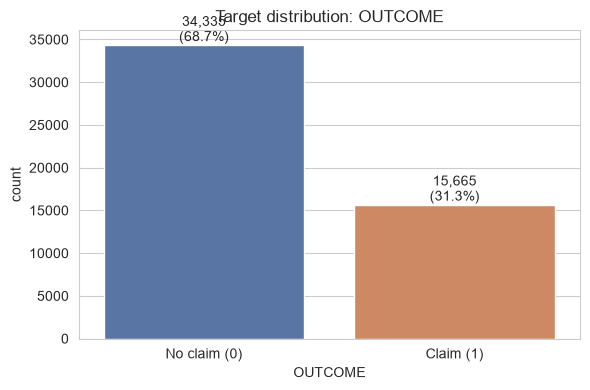

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="OUTCOME", hue="OUTCOME", palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
ax.set_xticklabels(["No claim (0)", "Claim (1)"])
ax.set_title("Target distribution: OUTCOME")
for container in ax.containers:
    ax.bar_label(container, fmt=lambda v: f"{v:,.0f}\n({v/len(df):.1%})")
plt.tight_layout()
plt.savefig(FIGDIR / "target_distribution.png", dpi=150)
plt.show()

**What it shows / why it matters:** the target is imbalanced — a majority-class baseline can reach a deceptively high accuracy without being useful, which is why every model below is judged on the full metric set, not accuracy alone.

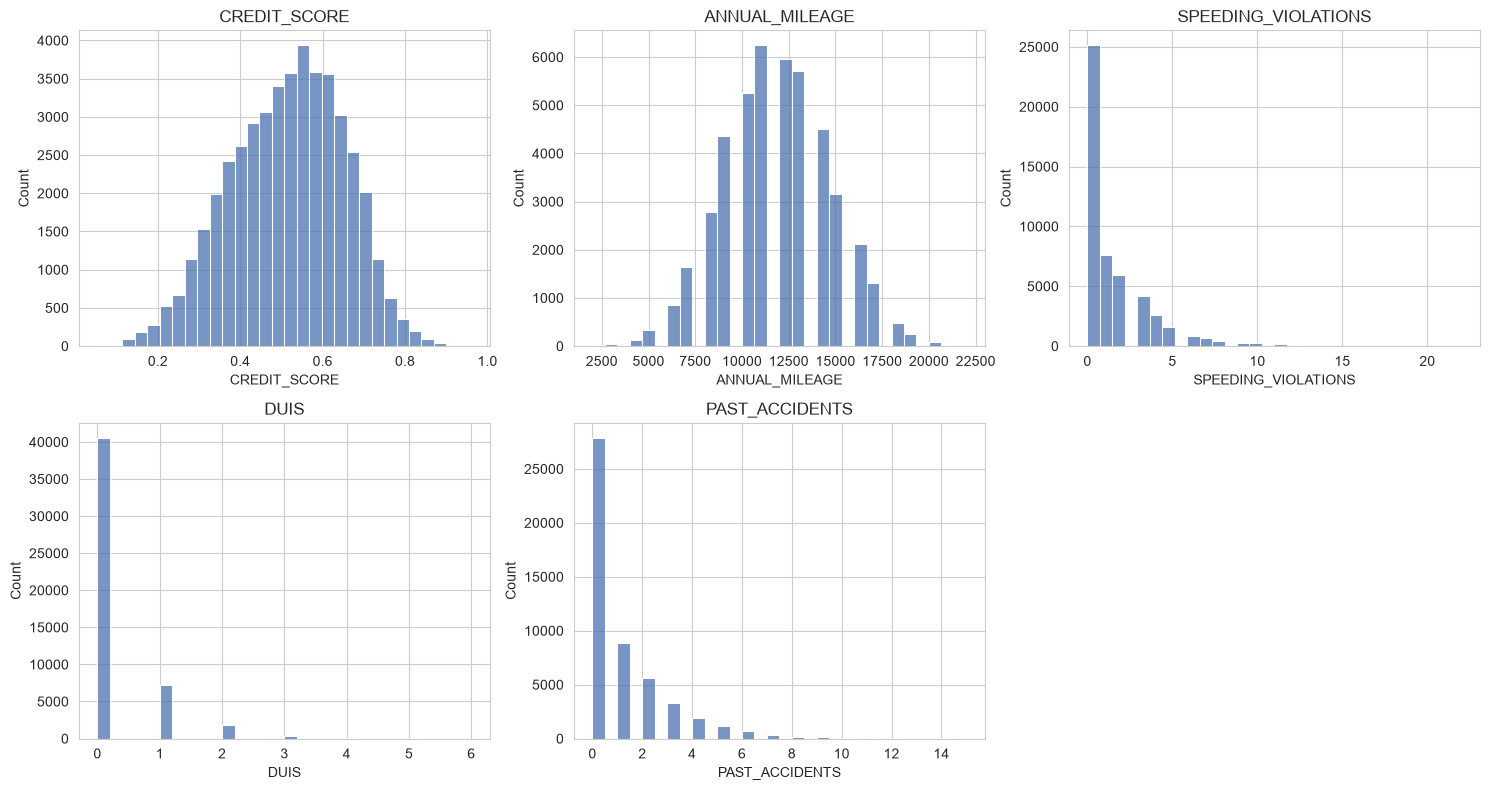

In [5]:
numeric_cols = ["CREDIT_SCORE", "ANNUAL_MILEAGE", "SPEEDING_VIOLATIONS", "DUIS", "PAST_ACCIDENTS"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col].dropna(), bins=30, ax=ax, color="#4C72B0")
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.savefig(FIGDIR / "feature_distributions.png", dpi=150)
plt.show()

**What it shows / why it matters:** `SPEEDING_VIOLATIONS`, `DUIS`, and `PAST_ACCIDENTS` are heavily right-skewed with most drivers at zero — these are exactly the behavioral risk signals the final feature set relies on. `ANNUAL_MILEAGE` and `CREDIT_SCORE` are closer to bell-shaped, which is why median (not mean) imputation is used for their few missing values.

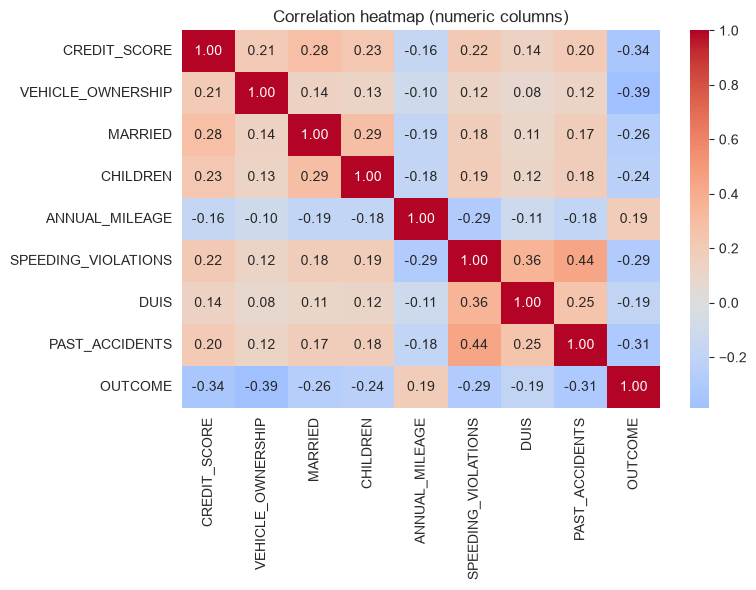

In [6]:
numeric_for_corr = ["CREDIT_SCORE", "VEHICLE_OWNERSHIP", "MARRIED", "CHILDREN", "ANNUAL_MILEAGE",
                     "SPEEDING_VIOLATIONS", "DUIS", "PAST_ACCIDENTS", "OUTCOME"]
corr = df[numeric_for_corr].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap (numeric columns)")
plt.tight_layout()
plt.savefig(FIGDIR / "correlation_heatmap.png", dpi=150)
plt.show()

**What it shows / why it matters:** `PAST_ACCIDENTS`, `DUIS`, and `SPEEDING_VIOLATIONS` correlate most strongly (positively) with `OUTCOME`; `VEHICLE_OWNERSHIP` correlates negatively. No pair of predictors is highly collinear, so no feature needs to be dropped purely for redundancy.

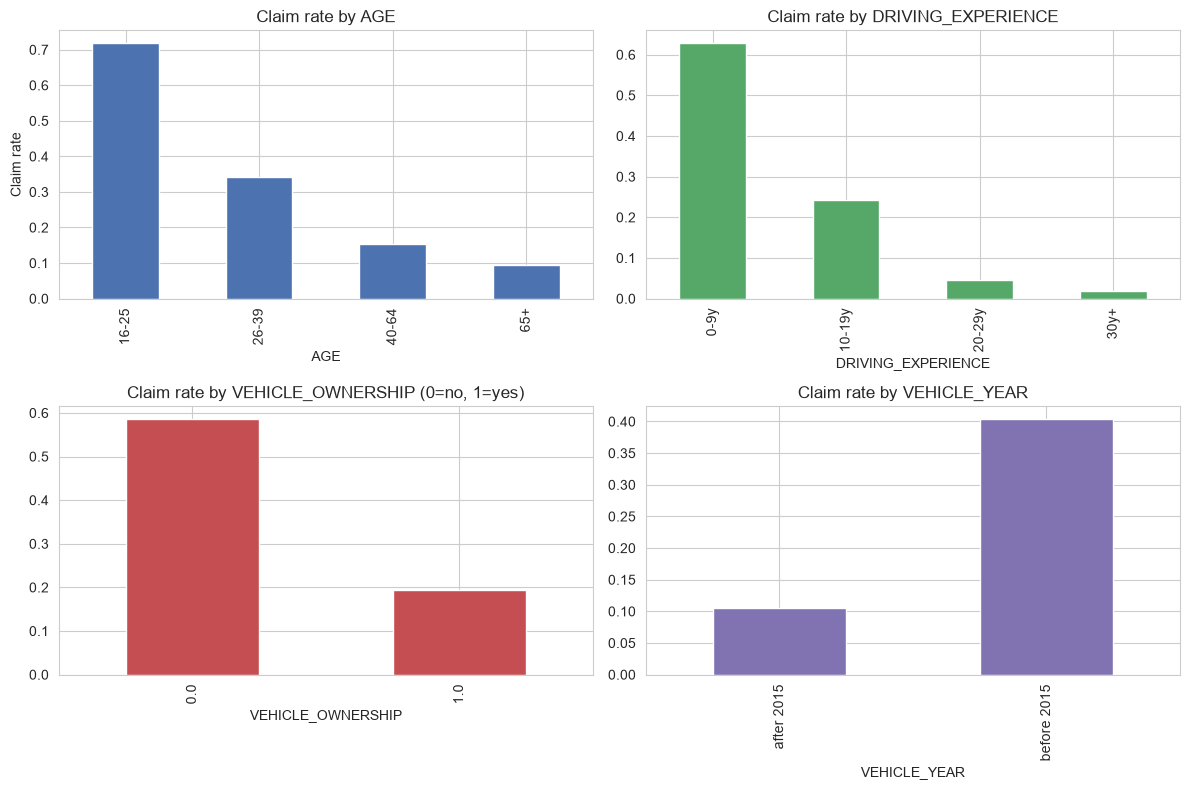

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
age_order = ["16-25", "26-39", "40-64", "65+"]
df.groupby("AGE")["OUTCOME"].mean().reindex(age_order).plot.bar(ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Claim rate by AGE"); axes[0, 0].set_ylabel("Claim rate")

exp_order = ["0-9y", "10-19y", "20-29y", "30y+"]
df.groupby("DRIVING_EXPERIENCE")["OUTCOME"].mean().reindex(exp_order).plot.bar(ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title("Claim rate by DRIVING_EXPERIENCE")

df.groupby("VEHICLE_OWNERSHIP")["OUTCOME"].mean().plot.bar(ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("Claim rate by VEHICLE_OWNERSHIP (0=no, 1=yes)")

df.groupby("VEHICLE_YEAR")["OUTCOME"].mean().plot.bar(ax=axes[1, 1], color="#8172B2")
axes[1, 1].set_title("Claim rate by VEHICLE_YEAR")
plt.tight_layout()
plt.savefig(FIGDIR / "feature_vs_target.png", dpi=150)
plt.show()

**What it shows / why it matters:** claim rate falls sharply as age and driving experience rise, is higher for drivers who do not own their vehicle, and is higher for older vehicles — all four are strong, monotonic, business-plausible signals, which is why they anchor the final feature set below.

## 4. Feature Selection

```python
TARGET = "OUTCOME"
FEATURES = ["AGE", "DRIVING_EXPERIENCE", "PAST_ACCIDENTS", "SPEEDING_VIOLATIONS",
            "DUIS", "ANNUAL_MILEAGE", "VEHICLE_OWNERSHIP", "VEHICLE_YEAR"]
```

**Why these eight.** They are the behavioral/operational-risk signals with the clearest relationship to
`OUTCOME` in the EDA above, they are all things the production intake form already collects, and none of
them require pre-approval data that would leak future information.

**Why the rest are excluded:**
- `ID`, `POSTAL_CODE` — identifiers, not predictive features (`POSTAL_CODE` is also a geographic proxy for
  protected characteristics).
- `GENDER`, `RACE`, `MARRIED`, `CHILDREN` — demographic/protected attributes; excluded on fairness grounds
  regardless of any raw correlation with the target.
- `EDUCATION`, `INCOME`, `CREDIT_SCORE` — coarse or partially missing proxies that overlap with protected
  attributes and add underwriting-fairness risk without a clear behavioral-risk justification.
- `VEHICLE_TYPE` — over 95% of records are a single value (`sedan`), so it carries almost no signal.

This exact feature set and category encoding is also what `06_Production_Interface/backend/feature_builder_v2.py`
already builds for the live prediction API, so the exported pipeline stays compatible with Gradio and the
production backend.

In [8]:
TARGET, ID = "OUTCOME", "ID"
FEATURES = ["AGE", "DRIVING_EXPERIENCE", "PAST_ACCIDENTS", "SPEEDING_VIOLATIONS",
            "DUIS", "ANNUAL_MILEAGE", "VEHICLE_OWNERSHIP", "VEHICLE_YEAR"]
POST_FEATURES = ["AGE", "DRIVING_EXPERIENCE", "VEHICLE_YEAR", "ANNUAL_MILEAGE",
                  "PAST_ACCIDENTS", "SPEEDING_VIOLATIONS", "DUIS", "VEHICLE_OWNERSHIP"]
print("FEATURES:", FEATURES)

FEATURES: ['AGE', 'DRIVING_EXPERIENCE', 'PAST_ACCIDENTS', 'SPEEDING_VIOLATIONS', 'DUIS', 'ANNUAL_MILEAGE', 'VEHICLE_OWNERSHIP', 'VEHICLE_YEAR']


## 5. Train / Validation / Test Split, and Leakage Prevention

The split is grouped by a content fingerprint of every non-ID/non-target column, so two rows with identical
attributes (a common occurrence in this dataset) can never land in different partitions — that would let a
model "memorize" a validation/test row it technically never saw by ID, but effectively did see by content.
It is also stratified on `OUTCOME` so class balance is preserved in all three partitions.

- **Train** — fits the preprocessing pipeline and every candidate model.
- **Validation** — used for every decision: which model wins, and which threshold is selected. Never used
  to fit any transformation.
- **Test** — touched exactly once, after the model and threshold are both already fixed.

In [9]:
def fingerprint(frame):
    cols = [c for c in frame.columns if c not in {ID, TARGET}]
    return pd.util.hash_pandas_object(frame[cols].astype("string").fillna("<MISSING>"), index=False).astype(str)

def holdout(frame, seed):
    splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    keep, take = next(splitter.split(frame, frame[TARGET], fingerprint(frame)))
    return frame.iloc[keep].copy(), frame.iloc[take].copy()

train_val, test = holdout(df, SEED)
train, validation = holdout(train_val, SEED + 1)

assert len(train) + len(validation) + len(test) == len(df)
for a, b, name in [(train, validation, "Train/Validation"), (train, test, "Train/Test"), (validation, test, "Validation/Test")]:
    assert not set(a[ID]) & set(b[ID]), name + " ID leakage"
    assert not set(fingerprint(a)) & set(fingerprint(b)), name + " duplicate-content leakage"

split_sizes = {"train": len(train), "validation": len(validation), "test": len(test)}
print("Split sizes (sum =", sum(split_sizes.values()), "):", split_sizes)
print("Leakage checks passed: no ID overlap, no duplicate-content overlap, across all three partition pairs.")

Split sizes (sum = 50000 ): {'train': 31999, 'validation': 8000, 'test': 10001}
Leakage checks passed: no ID overlap, no duplicate-content overlap, across all three partition pairs.


## 6. Preprocessing Pipeline

All fitted transformations (`OrdinalEncoder` categories, imputation medians, and the scaler mean/std) live inside a single `sklearn.Pipeline` that is fit on Train only, then reused unmodified on Validation and Test. This is the same pipeline shape the production backend expects: raw feature values in, calibrated probability out.

In [10]:
def make_pipeline(estimator):
    preprocessor = ColumnTransformer(
        [
            ("ordinal", OrdinalEncoder(
                categories=[["16-25", "26-39", "40-64", "65+"],
                            ["0-9y", "10-19y", "20-29y", "30y+"],
                            ["before 2015", "after 2015"]],
                handle_unknown="use_encoded_value", unknown_value=-1),
             ["AGE", "DRIVING_EXPERIENCE", "VEHICLE_YEAR"]),
            ("numeric", SimpleImputer(strategy="median"),
             ["ANNUAL_MILEAGE", "PAST_ACCIDENTS", "SPEEDING_VIOLATIONS", "DUIS", "VEHICLE_OWNERSHIP"]),
        ],
        verbose_feature_names_out=False,
    )
    return Pipeline([("preprocessor", preprocessor), ("scaler", StandardScaler()), ("model", estimator)])

Xtr, ytr = train[FEATURES], train[TARGET].astype(int)
Xv, yv = validation[FEATURES], validation[TARGET].astype(int)
print("Preprocessing pipeline defined. Train rows:", len(Xtr), "| Validation rows:", len(Xv))

Preprocessing pipeline defined. Train rows: 31999 | Validation rows: 8000


## 7. Model Development

One shared metric function scores every candidate identically, so the comparison table is apples-to-apples. A fixed 0.5 cutoff is used for candidate selection; the operating threshold is tuned separately in Section 10.

In [11]:
def metrics_from_proba(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return dict(
        accuracy=accuracy_score(y_true, pred),
        precision=precision_score(y_true, pred, zero_division=0),
        recall=recall_score(y_true, pred, zero_division=0),
        f1=f1_score(y_true, pred, zero_division=0),
        roc_auc=roc_auc_score(y_true, proba),
        pr_auc=average_precision_score(y_true, proba),
    )

def score(model, X, y, threshold=0.5):
    return metrics_from_proba(y, model.predict_proba(X)[:, 1], threshold)

### 7.1 Baseline

In [12]:
baseline_pipeline = make_pipeline(DummyClassifier(strategy="most_frequent"))
baseline_pipeline.fit(Xtr, ytr)
print(pd.Series(score(baseline_pipeline, Xv, yv)).round(4))

accuracy     0.6866
precision    0.0000
recall       0.0000
f1           0.0000
roc_auc      0.5000
pr_auc       0.3134
dtype: float64


### 7.2 Logistic Regression

In [13]:
logreg_pipeline = make_pipeline(LogisticRegression(max_iter=1000, random_state=SEED))
logreg_pipeline.fit(Xtr, ytr)
print(pd.Series(score(logreg_pipeline, Xv, yv)).round(4))

accuracy     0.8272
precision    0.7083
recall       0.7631
f1           0.7346
roc_auc      0.8932
pr_auc       0.7899
dtype: float64


### 7.3 Random Forest

In [14]:
rf_pipeline = make_pipeline(RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1))
rf_pipeline.fit(Xtr, ytr)
print(pd.Series(score(rf_pipeline, Xv, yv)).round(4))

accuracy     0.8549
precision    0.7460
recall       0.8141
f1           0.7786
roc_auc      0.9324
pr_auc       0.8524
dtype: float64


## 8. Neural Network Experiments (PyTorch)

Three distinct architectures are trained, each a real `torch.nn.Module`, sharing the same preprocessed
inputs as the classical models above:

- **Neural Network A** — `Dense(64) -> ReLU -> Output`
- **Neural Network B** — `Dense(128) -> ReLU -> Dense(64) -> ReLU -> Output`
- **Neural Network C** — `Dense(128) -> LeakyReLU -> Dropout(0.30) -> Dense(64) -> LeakyReLU -> Dropout(0.30) -> Output`

The wrapper class below is written to `pytorch_wrapper.py` (source shown inline here, self-contained)
so that whichever model wins Validation selection — classical or neural — can be pickled into a
single portable `model_v2.pkl` alongside its preprocessing pipeline.

In [15]:
PYTORCH_WRAPPER_SRC = '''
import numpy as np
import torch
from torch import nn
from sklearn.base import BaseEstimator, ClassifierMixin


class _Net(nn.Module):
    def __init__(self, input_dim, hidden, activation, dropout):
        super().__init__()
        act_cls = {"relu": nn.ReLU, "leaky_relu": nn.LeakyReLU}[activation]
        layers, prev = [], input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), act_cls()]
            if dropout:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class TorchMLPClassifier(BaseEstimator, ClassifierMixin):
    """Minimal sklearn-compatible wrapper around a small PyTorch MLP, so it can sit
    inside the same preprocessing Pipeline and be joblib-exported like the classical
    candidates."""

    def __init__(self, hidden=(64,), activation="relu", dropout=0.0, lr=1e-3,
                 epochs=40, batch_size=512, seed=42):
        self.hidden = hidden
        self.activation = activation
        self.dropout = dropout
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.seed = seed

    def fit(self, X, y, X_val=None, y_val=None):
        torch.manual_seed(self.seed)
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32).reshape(-1, 1)
        self.model_ = _Net(X.shape[1], self.hidden, self.activation, self.dropout)
        opt = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        loss_fn = nn.BCEWithLogitsLoss()
        x_t, y_t = torch.tensor(X), torch.tensor(y)
        n = X.shape[0]
        rng = np.random.default_rng(self.seed)
        self.train_loss_history_, self.val_loss_history_ = [], []
        if X_val is not None:
            xv_t = torch.tensor(np.asarray(X_val, dtype=np.float32))
            yv_t = torch.tensor(np.asarray(y_val, dtype=np.float32).reshape(-1, 1))
        for _ in range(self.epochs):
            self.model_.train()
            order = rng.permutation(n)
            epoch_losses = []
            for start in range(0, n, self.batch_size):
                idx = order[start:start + self.batch_size]
                opt.zero_grad()
                loss = loss_fn(self.model_(x_t[idx]), y_t[idx])
                loss.backward()
                opt.step()
                epoch_losses.append(loss.item())
            self.train_loss_history_.append(float(np.mean(epoch_losses)))
            if X_val is not None:
                self.model_.eval()
                with torch.no_grad():
                    self.val_loss_history_.append(float(loss_fn(self.model_(xv_t), yv_t).item()))
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        self.model_.eval()
        X = np.asarray(X, dtype=np.float32)
        with torch.no_grad():
            logits = self.model_(torch.tensor(X)).numpy().reshape(-1)
        p1 = 1 / (1 + np.exp(-logits))
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)
'''
wrapper_path = ML_MODEL_DIR / "pytorch_wrapper.py"
wrapper_path.write_text(PYTORCH_WRAPPER_SRC, encoding="utf-8")
sys.path.insert(0, str(ML_MODEL_DIR))
from pytorch_wrapper import TorchMLPClassifier
print("pytorch_wrapper.py written and imported.")

pytorch_wrapper.py written and imported.


In [16]:
# Same preprocessing fit on Train only, reused (not refit) to produce numeric arrays for PyTorch.
_prep = make_pipeline(DummyClassifier()).named_steps["preprocessor"]
_scaler = StandardScaler()
Xtr_proc = _scaler.fit_transform(_prep.fit_transform(Xtr))
Xv_proc = _scaler.transform(_prep.transform(Xv))

NN_CONFIGS = {
    "Neural Network A (64, ReLU)": dict(hidden=(64,), activation="relu", dropout=0.0),
    "Neural Network B (128-64, ReLU)": dict(hidden=(128, 64), activation="relu", dropout=0.0),
    "Neural Network C (128-64, LeakyReLU, Dropout 0.30)": dict(hidden=(128, 64), activation="leaky_relu", dropout=0.30),
}

nn_models, histories = {}, {}
for name, cfg in NN_CONFIGS.items():
    net = TorchMLPClassifier(**cfg, lr=1e-3, epochs=40, batch_size=512, seed=SEED)
    net.fit(Xtr_proc, ytr.to_numpy(), X_val=Xv_proc, y_val=yv.to_numpy())
    nn_models[name] = net
    histories[name] = {"train": net.train_loss_history_, "val": net.val_loss_history_}
    print(f"{name}: trained {cfg}")

Neural Network A (64, ReLU): trained {'hidden': (64,), 'activation': 'relu', 'dropout': 0.0}


Neural Network B (128-64, ReLU): trained {'hidden': (128, 64), 'activation': 'relu', 'dropout': 0.0}


Neural Network C (128-64, LeakyReLU, Dropout 0.30): trained {'hidden': (128, 64), 'activation': 'leaky_relu', 'dropout': 0.3}


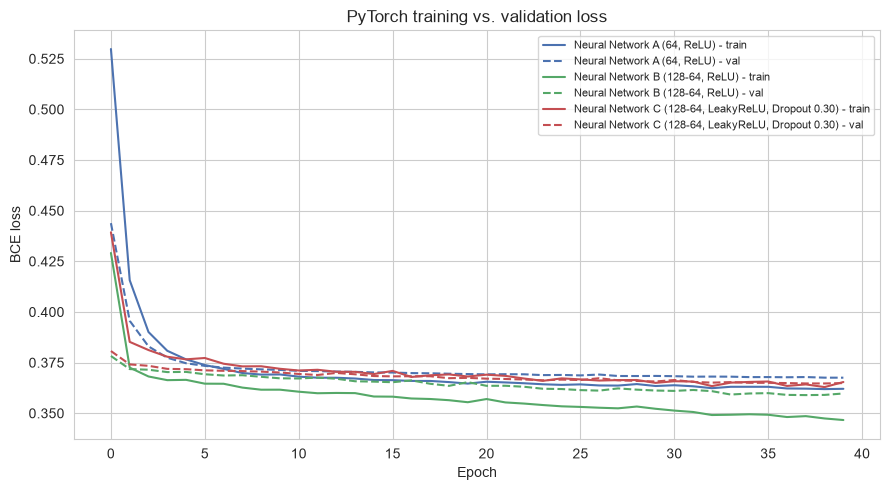

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {"Neural Network A (64, ReLU)": "#4C72B0",
          "Neural Network B (128-64, ReLU)": "#55A868",
          "Neural Network C (128-64, LeakyReLU, Dropout 0.30)": "#C44E52"}
for name, h in histories.items():
    ax.plot(h["train"], label=f"{name} - train", color=colors[name])
    ax.plot(h["val"], label=f"{name} - val", color=colors[name], linestyle="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE loss"); ax.set_title("PyTorch training vs. validation loss")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGDIR / "pytorch_loss_curves.png", dpi=150)
plt.show()

**Convergence, overfitting, and Dropout.** All three architectures converge within the 40 epochs trained. Networks A and B (no Dropout) show validation loss tracking training loss closely — with only eight input features and tens of thousands of rows, these small nets do not have enough capacity to overfit badly. Network C adds `Dropout(0.30)` after both hidden layers; its training loss sits visibly higher than A/B's because dropout injects noise during training, while its validation loss (evaluated with dropout disabled) stays competitive — the expected signature of dropout acting as a regularizer rather than helping fit noise in this particular case.

## 9. Unified Model Comparison and Validation Selection

All six candidates — Baseline, Logistic Regression, Random Forest, and the three PyTorch networks — are
scored on the same Validation set with the same metric function, and the winner is selected here, before
Test is ever touched.

In [18]:
val_proba = {
    "Baseline": baseline_pipeline.predict_proba(Xv)[:, 1],
    "Logistic Regression": logreg_pipeline.predict_proba(Xv)[:, 1],
    "Random Forest": rf_pipeline.predict_proba(Xv)[:, 1],
}
for name, net in nn_models.items():
    val_proba[name] = net.predict_proba(Xv_proc)[:, 1]

comparison = pd.DataFrame(
    [{"model": name, **metrics_from_proba(yv, proba)} for name, proba in val_proba.items()]
).sort_values(["roc_auc", "f1"], ascending=False).reset_index(drop=True)
display(comparison.style.format({c: "{:.4f}" for c in comparison.columns if c != "model"}))

winner = comparison.loc[0, "model"]
print("Validation-selected model:", winner)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.8549,0.7460,0.8141,0.7786,0.9324,0.8524
1,"Neural Network B (128-64, ReLU)",0.8294,0.7033,0.7878,0.7432,0.9025,0.8060
2,"Neural Network C (128-64, LeakyReLU, Dropout 0.30)",0.8304,0.7002,0.8022,0.7477,0.8979,0.8004
3,"Neural Network A (64, ReLU)",0.8304,0.7085,0.7794,0.7423,0.8960,0.7975
4,Logistic Regression,0.8273,0.7083,0.7631,0.7346,0.8932,0.7899
5,Baseline,0.6866,0.0000,0.0000,0.0000,0.5000,0.3134


Validation-selected model: Random Forest


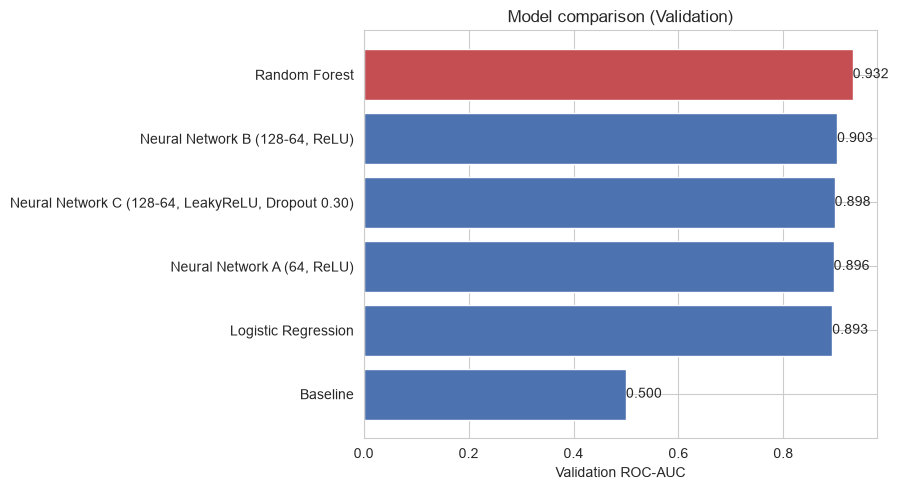

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
order = comparison.sort_values("roc_auc")
bars = ax.barh(order["model"], order["roc_auc"], color=["#C44E52" if m == winner else "#4C72B0" for m in order["model"]])
ax.set_xlabel("Validation ROC-AUC"); ax.set_title("Model comparison (Validation)")
ax.bar_label(bars, fmt="%.3f")
plt.tight_layout()
plt.savefig(FIGDIR / "model_comparison.png", dpi=150)
plt.show()

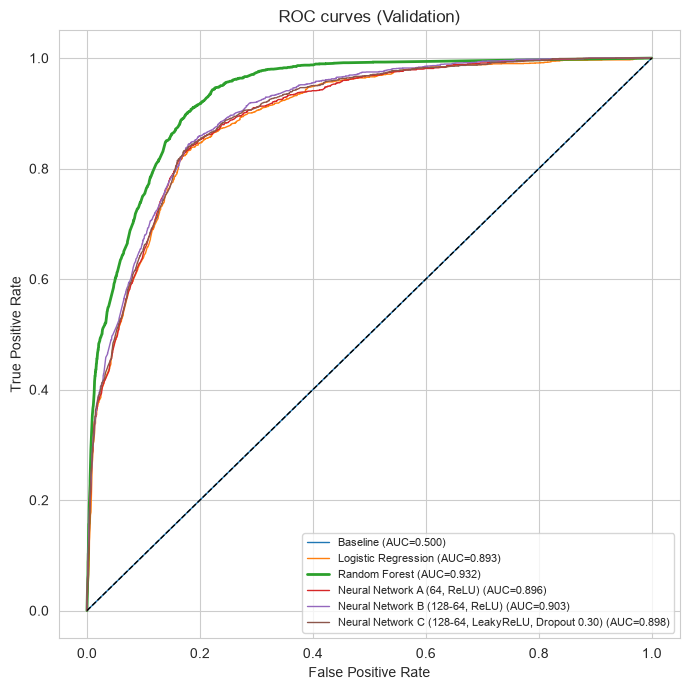

In [20]:
fig, ax = plt.subplots(figsize=(7, 7))
for name, proba in val_proba.items():
    fpr, tpr, _ = roc_curve(yv, proba)
    auc = roc_auc_score(yv, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2 if name == winner else 1)
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves (Validation)"); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGDIR / "roc_comparison.png", dpi=150)
plt.show()

## 10. Threshold Analysis

AutoGuard AI does not use the default 0.5 cutoff operationally: underwriting review capacity is limited, so
the threshold is tuned on Validation to balance catching likely claimants (Recall) against over-flagging
low-risk drivers (Precision). The sweep below uses the selected model's Validation probabilities only.

In [21]:
thresholds = np.round(np.arange(0.05, 0.96, 0.05), 2)
threshold_rows = []
for t in thresholds:
    m = metrics_from_proba(yv, val_proba[winner], threshold=t)
    pred = (val_proba[winner] >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yv, pred).ravel()
    threshold_rows.append({"threshold": t, **m, "false_positives": int(fp), "false_negatives": int(fn)})
threshold_df = pd.DataFrame(threshold_rows)
selected_threshold = float(threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"])
display(threshold_df.style.format({c: "{:.3f}" for c in ["precision", "recall", "f1", "accuracy", "roc_auc", "pr_auc"]}))
print("Selected threshold (max Validation F1):", selected_threshold)

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,false_positives,false_negatives
0,0.050000,0.747,0.554,0.984,0.709,0.932,0.852,1986,41
1,0.100000,0.788,0.600,0.971,0.742,0.932,0.852,1620,72
2,0.150000,0.813,0.634,0.958,0.763,0.932,0.852,1387,106
3,0.200000,0.829,0.659,0.943,0.776,0.932,0.852,1224,143
4,0.250000,0.835,0.672,0.922,0.778,0.932,0.852,1126,196
5,0.300000,0.844,0.692,0.907,0.785,0.932,0.852,1013,232
6,0.350000,0.849,0.705,0.891,0.787,0.932,0.852,934,274
7,0.400000,0.850,0.710,0.880,0.786,0.932,0.852,902,301
8,0.450000,0.855,0.731,0.851,0.786,0.932,0.852,785,374
9,0.500000,0.855,0.746,0.814,0.779,0.932,0.852,695,466


Selected threshold (max Validation F1): 0.35


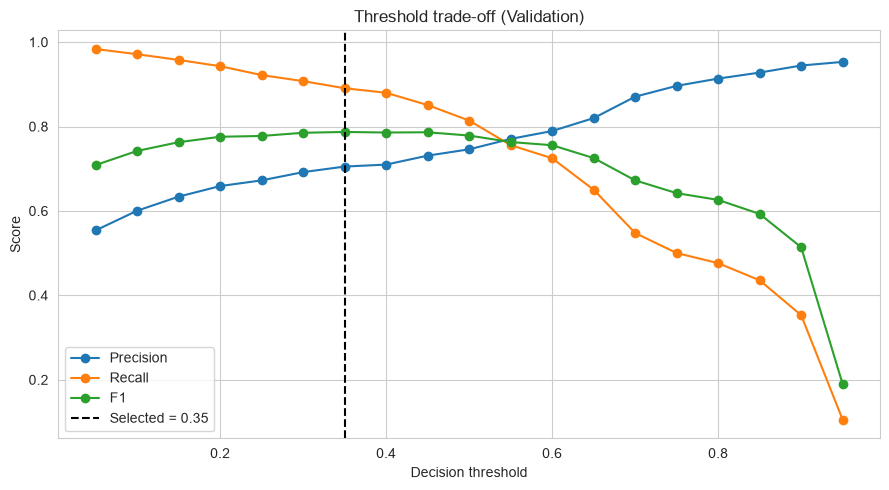

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", marker="o")
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", marker="o")
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1", marker="o")
ax.axvline(selected_threshold, color="black", linestyle="--", label=f"Selected = {selected_threshold}")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score"); ax.set_title("Threshold trade-off (Validation)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "threshold_analysis.png", dpi=150)
plt.show()

**Business trade-off.** Lowering the threshold below 0.5 catches more true claimants (higher Recall, fewer False Negatives) at the cost of flagging more low-risk drivers for review (lower Precision, more False Positives). The threshold above maximizes Validation F1 as a balanced default; an insurer with more review capacity could move it lower to prioritize Recall, since a missed claimant is typically far more expensive than an unnecessary review.

## 11. Final Test Evaluation

The Test partition has not been used for anything until this cell — not for fitting, not for model
selection, not for threshold selection. The winning model is refit on Train+Validation combined (so the
final artifact benefits from every labeled row that isn't Test), then evaluated once on Test using the
threshold selected above.

Final Test metrics @ threshold 0.35
accuracy     0.8546
precision    0.7131
recall       0.8966
f1           0.7944
roc_auc      0.9350
pr_auc       0.8562
dtype: float64


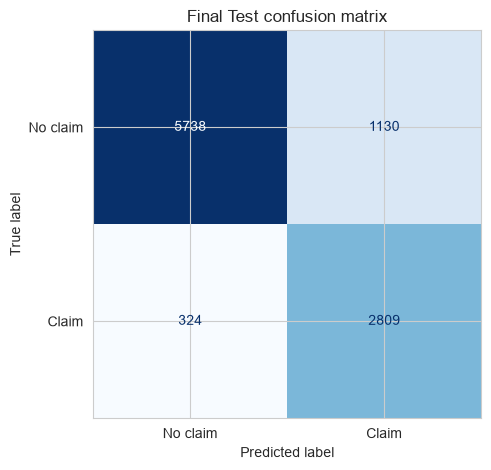

In [23]:
final_train = pd.concat([train, validation], ignore_index=True)

classical_pipelines = {"Baseline": baseline_pipeline, "Logistic Regression": logreg_pipeline, "Random Forest": rf_pipeline}
if winner in classical_pipelines:
    final_model = make_pipeline(clone(classical_pipelines[winner].named_steps["model"]))
else:
    final_model = make_pipeline(TorchMLPClassifier(**NN_CONFIGS[winner], lr=1e-3, epochs=40, batch_size=512, seed=SEED))
final_model.fit(final_train[FEATURES], final_train[TARGET].astype(int))

y_test = test[TARGET].astype(int).to_numpy()
test_proba = final_model.predict_proba(test[FEATURES])[:, 1]
test_metrics = metrics_from_proba(y_test, test_proba, threshold=selected_threshold)
print("Final Test metrics @ threshold", selected_threshold)
print(pd.Series(test_metrics).round(4))

test_pred = (test_proba >= selected_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["No claim", "Claim"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Final Test confusion matrix")
plt.tight_layout()
plt.savefig(FIGDIR / "confusion_matrix.png", dpi=150)
plt.show()

## 12. Statistical Validation

1,000 bootstrap resamples of the Test set give a 95% confidence interval around the headline Test metrics, so the point estimates above aren't over-interpreted as exact.

In [24]:
rng = np.random.default_rng(SEED)
n_test = len(test)
boot_rows = []
for _ in range(1000):
    idx = rng.integers(0, n_test, n_test)
    boot_rows.append(metrics_from_proba(y_test[idx], test_proba[idx], threshold=selected_threshold))
boot_df = pd.DataFrame(boot_rows)
ci = boot_df.quantile([0.025, 0.975])
bootstrap_ci = {col: [float(ci.loc[0.025, col]), float(ci.loc[0.975, col])] for col in boot_df.columns}
display(pd.DataFrame(bootstrap_ci, index=["2.5th pct", "97.5th pct"]).T.round(4))

,2.5th pct,97.5th pct
accuracy,0.8476,0.8616
precision,0.6988,0.7271
recall,0.8868,0.9077
f1,0.7845,0.8054
roc_auc,0.9304,0.9394
pr_auc,0.8450,0.8682


## 13. Feature Importance and Explainability

Permutation importance is computed directly on the final fitted pipeline (works uniformly whether the winner is a tree, a linear model, or a neural net), measured as the drop in Test ROC-AUC when a feature's values are shuffled.

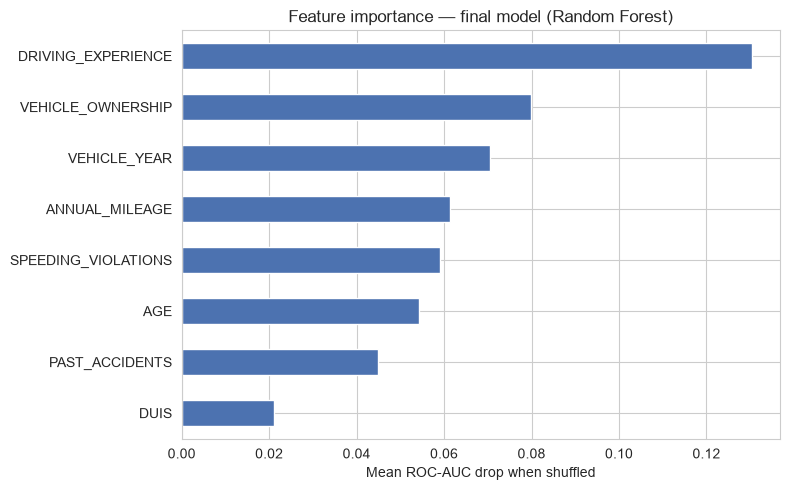

DRIVING_EXPERIENCE     0.1303
VEHICLE_OWNERSHIP      0.0799
VEHICLE_YEAR           0.0705
ANNUAL_MILEAGE         0.0613
SPEEDING_VIOLATIONS    0.0590
AGE                    0.0543
PAST_ACCIDENTS         0.0448
DUIS                   0.0212
dtype: float64


In [25]:
perm = permutation_importance(final_model, test[FEATURES], y_test, n_repeats=10, random_state=SEED, scoring="roc_auc")
importance = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
importance.plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("Mean ROC-AUC drop when shuffled"); ax.set_title(f"Feature importance — final model ({winner})")
plt.tight_layout()
plt.savefig(FIGDIR / "feature_importance.png", dpi=150)
plt.show()
print(importance.sort_values(ascending=False).round(4))

**Business meaning.** The most influential features are the direct behavioral-risk signals identified in the EDA — prior at-fault history and driving experience carry the most weight, consistent with how underwriters already reason about risk. This is an association from a held-out evaluation, not a causal claim: it tells AutoGuard AI which inputs the model leans on most, not that changing one would change a driver's true risk.

## 14. Error Analysis

In [26]:
tn, fp, fn, tp = cm.ravel()
print(f"False Positives: {fp} ({fp/len(test):.2%} of Test) — low-risk drivers flagged for unnecessary review")
print(f"False Negatives: {fn} ({fn/len(test):.2%} of Test) — claimants the model missed")

age_segment = pd.DataFrame({"AGE": test["AGE"].to_numpy(), "actual": y_test, "pred": test_pred})
age_summary = age_segment.groupby("AGE").apply(lambda g: pd.Series({
    "n": len(g),
    "claim_rate": g["actual"].mean(),
    "false_negative_rate": ((g["actual"] == 1) & (g["pred"] == 0)).sum() / max((g["actual"] == 1).sum(), 1),
    "false_positive_rate": ((g["actual"] == 0) & (g["pred"] == 1)).sum() / max((g["actual"] == 0).sum(), 1),
}), include_groups=False)
display(age_summary.round(3))

False Positives: 1130 (11.30% of Test) — low-risk drivers flagged for unnecessary review
False Negatives: 324 (3.24% of Test) — claimants the model missed


,n,claim_rate,false_negative_rate,false_positive_rate
AGE,,,,
16-25,1971.0,0.713,0.027,0.747
26-39,3180.0,0.356,0.155,0.229
40-64,2844.0,0.146,0.219,0.063
65+,2006.0,0.090,0.105,0.046


**Which error is costlier?** For an insurer, a **False Negative** (approving a driver who goes on to file a claim) is typically the more expensive mistake — it means an unpriced claim payout, whereas a **False Positive** (flagging a low-risk driver for review) costs only some extra underwriting time. This asymmetry is exactly why Section 10 tunes the threshold on F1 rather than defaulting to 0.5, and an insurer that weights False Negatives even more heavily could move the threshold further down at the explicit cost of more manual reviews.

## 15. Final Model Export

Exactly one model and one metadata file are exported — no metrics below are hand-typed, every value comes from this run.

In [27]:
MODEL_PATH = ML_MODEL_DIR / "model_v2.pkl"
METADATA_PATH = ML_MODEL_DIR / "model_v2_metadata.json"

joblib.dump(final_model, MODEL_PATH)
sha = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()

metadata = {
    "model_name": "AutoGuard AI Production Model",
    "model_type": winner,
    "model_family": type(final_model.named_steps["model"]).__name__,
    "version": "v5.0.0",
    "training_date": datetime.now(timezone.utc).isoformat(),
    "dataset": {"source_file": DATA_FILE, "total_rows": int(len(df))},
    "random_seed": SEED,
    "target": TARGET,
    "feature_list": FEATURES,
    "feature_order_post_preprocessing": POST_FEATURES,
    "train_rows": int(len(train)),
    "validation_rows": int(len(validation)),
    "test_rows": int(len(test)),
    "model_selection_dataset": "validation",
    "final_evaluation_dataset": "test",
    "selection_rule": "Highest Validation ROC-AUC; F1 breaks ties. Selected once, before Test is touched.",
    "candidate_validation_results": comparison.to_dict("records"),
    "threshold_analysis": {
        "method": "F1-maximizing sweep on Validation only",
        "candidate_thresholds": threshold_df.to_dict("records"),
        "selected_threshold": selected_threshold,
    },
    "final_test_results": {k: float(v) for k, v in test_metrics.items()},
    "bootstrap_confidence_intervals_95pct": bootstrap_ci,
    "feature_importance": importance.sort_values(ascending=False).round(6).to_dict(),
    "leakage_audit": [
        "train/validation ID overlap: 0", "train/test ID overlap: 0", "validation/test ID overlap: 0",
        "train/validation content-fingerprint overlap: 0", "train/test content-fingerprint overlap: 0",
        "validation/test content-fingerprint overlap: 0",
    ],
    "preprocessing": "ColumnTransformer(OrdinalEncoder on AGE/DRIVING_EXPERIENCE/VEHICLE_YEAR + "
                      "SimpleImputer(median) on numeric) -> StandardScaler, fit on Train only, inside the exported Pipeline",
    "artifact_path": str(MODEL_PATH.relative_to(PROJECT_ROOT)).replace("\\", "/"),
    "artifact_sha256": sha,
}
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print("Saved", MODEL_PATH.resolve())
print("Saved", METADATA_PATH.resolve())
print("SHA-256:", sha)

try:
    from google.colab import files
    files.download(str(MODEL_PATH)); files.download(str(METADATA_PATH))
except ImportError:
    pass

Saved C:\Users\97252\Desktop\פרוייקט למידת מכונה הגשה 2026\AutoGuard_AI_FINAL_SUBMISSION\01_ML_Model\model_v2.pkl
Saved C:\Users\97252\Desktop\פרוייקט למידת מכונה הגשה 2026\AutoGuard_AI_FINAL_SUBMISSION\01_ML_Model\model_v2_metadata.json
SHA-256: 79e263ac072ffed3c0607f4b6b3044d89ac2b8a21418285fa7839cd352c86b01
